In [35]:
import pandas as pd
from ace.constants import COL_GAME_TYPE
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
import os
boxed = pd.read_csv("../temp/session_number_exploration/boxed_2024-10-10_15.csv")

In [37]:
def get_participants_with_several_sessions_ids(df, gametype):
    # Initialize a set to store participant IDs that meet the criteria
    participants_with_both_sessions = set()

    if COL_GAME_TYPE in df.columns and df[COL_GAME_TYPE].iloc[0].lower() == gametype:
        # Group by participantId and get unique session numbers for each participant
        participant_sessions = df.groupby('participantId')['sessionNumber'].nunique()
        
        # Find participants with both session 0 and 1
        participants_with_both_sessions = set(
            participant_sessions[participant_sessions >= 2].index
        )

    # Convert the set to a sorted list for better readability
    participants_list = sorted(list(participants_with_both_sessions))

    print(f"Participants in '{gametype}' with two or more sessions:")
    return participants_list

get_participants_with_several_sessions_ids(boxed, "boxed")


Participants in 'boxed' with two or more sessions:


['042ef647-b695-438e-88cd-11a371f93641',
 '044d3a84-401b-4be7-bac5-c46d0a20f5fb',
 '053bf209-563d-4a92-b3d9-9bd6f118a116',
 '060620b1-bf41-438f-a48c-7ccdc8bac35e',
 '1770c18b-4fa3-452e-9ca0-d492741badfe',
 '18bd1c84-19b5-4586-baaf-095ddb5d416a',
 '18ec4010-cc75-4cf4-96ad-4082b2294ec1',
 '1d34c019-31c5-40f4-b79b-54a3080e38d8',
 '217c1e1a-50e7-4569-8a47-6c6f1dbc4a00',
 '248fdba5-6271-45a0-bae7-a7f0d31d6a89',
 '27adebf6-f6cf-439f-8cde-4b0df7b2362a',
 '2d3b19eb-65c1-4c56-9535-182af83d82ed',
 '30f5c784-9bfd-40c4-8e96-de23392ba2aa',
 '36f6ea18-de8f-4daf-89de-0c939756912d',
 '37c32847-3a71-420b-b698-3575bb1c3287',
 '3c5f6139-dea4-403f-87e1-0fc80f132dce',
 '3c71ea74-a9db-4fcb-a1c9-bf5cb3139d42',
 '3ea9c6b8-64f8-41af-a3a9-25663b167d49',
 '4435b542-d9b0-446c-9b43-87d7092a13ad',
 '4493221b-6aaa-456d-bf4c-087d9a71a961',
 '465a3057-4dd6-41bf-ba2a-b7aaa965454c',
 '46ce27f8-cecf-4a77-a2ec-378b49d68b3b',
 '4cf48490-7e79-4657-9ce8-26628f731e1a',
 '50840cb4-9ee9-4dee-b0cf-a4473b048b2c',
 '51ccc260-53da-

Analyzing session numbers for file: boxed
Session Number Distribution:
sessionNumber
0     846
1    7812
Name: count, dtype: int64


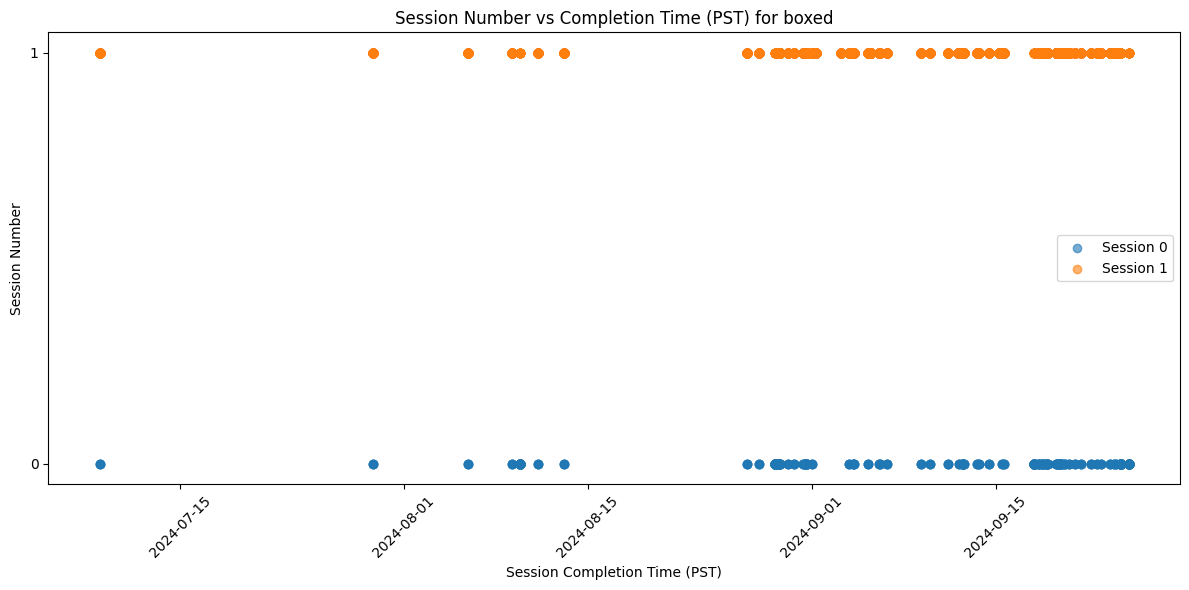

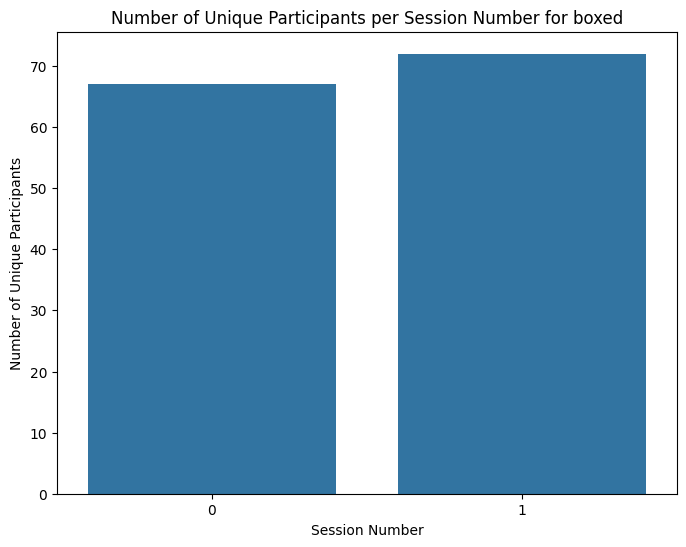

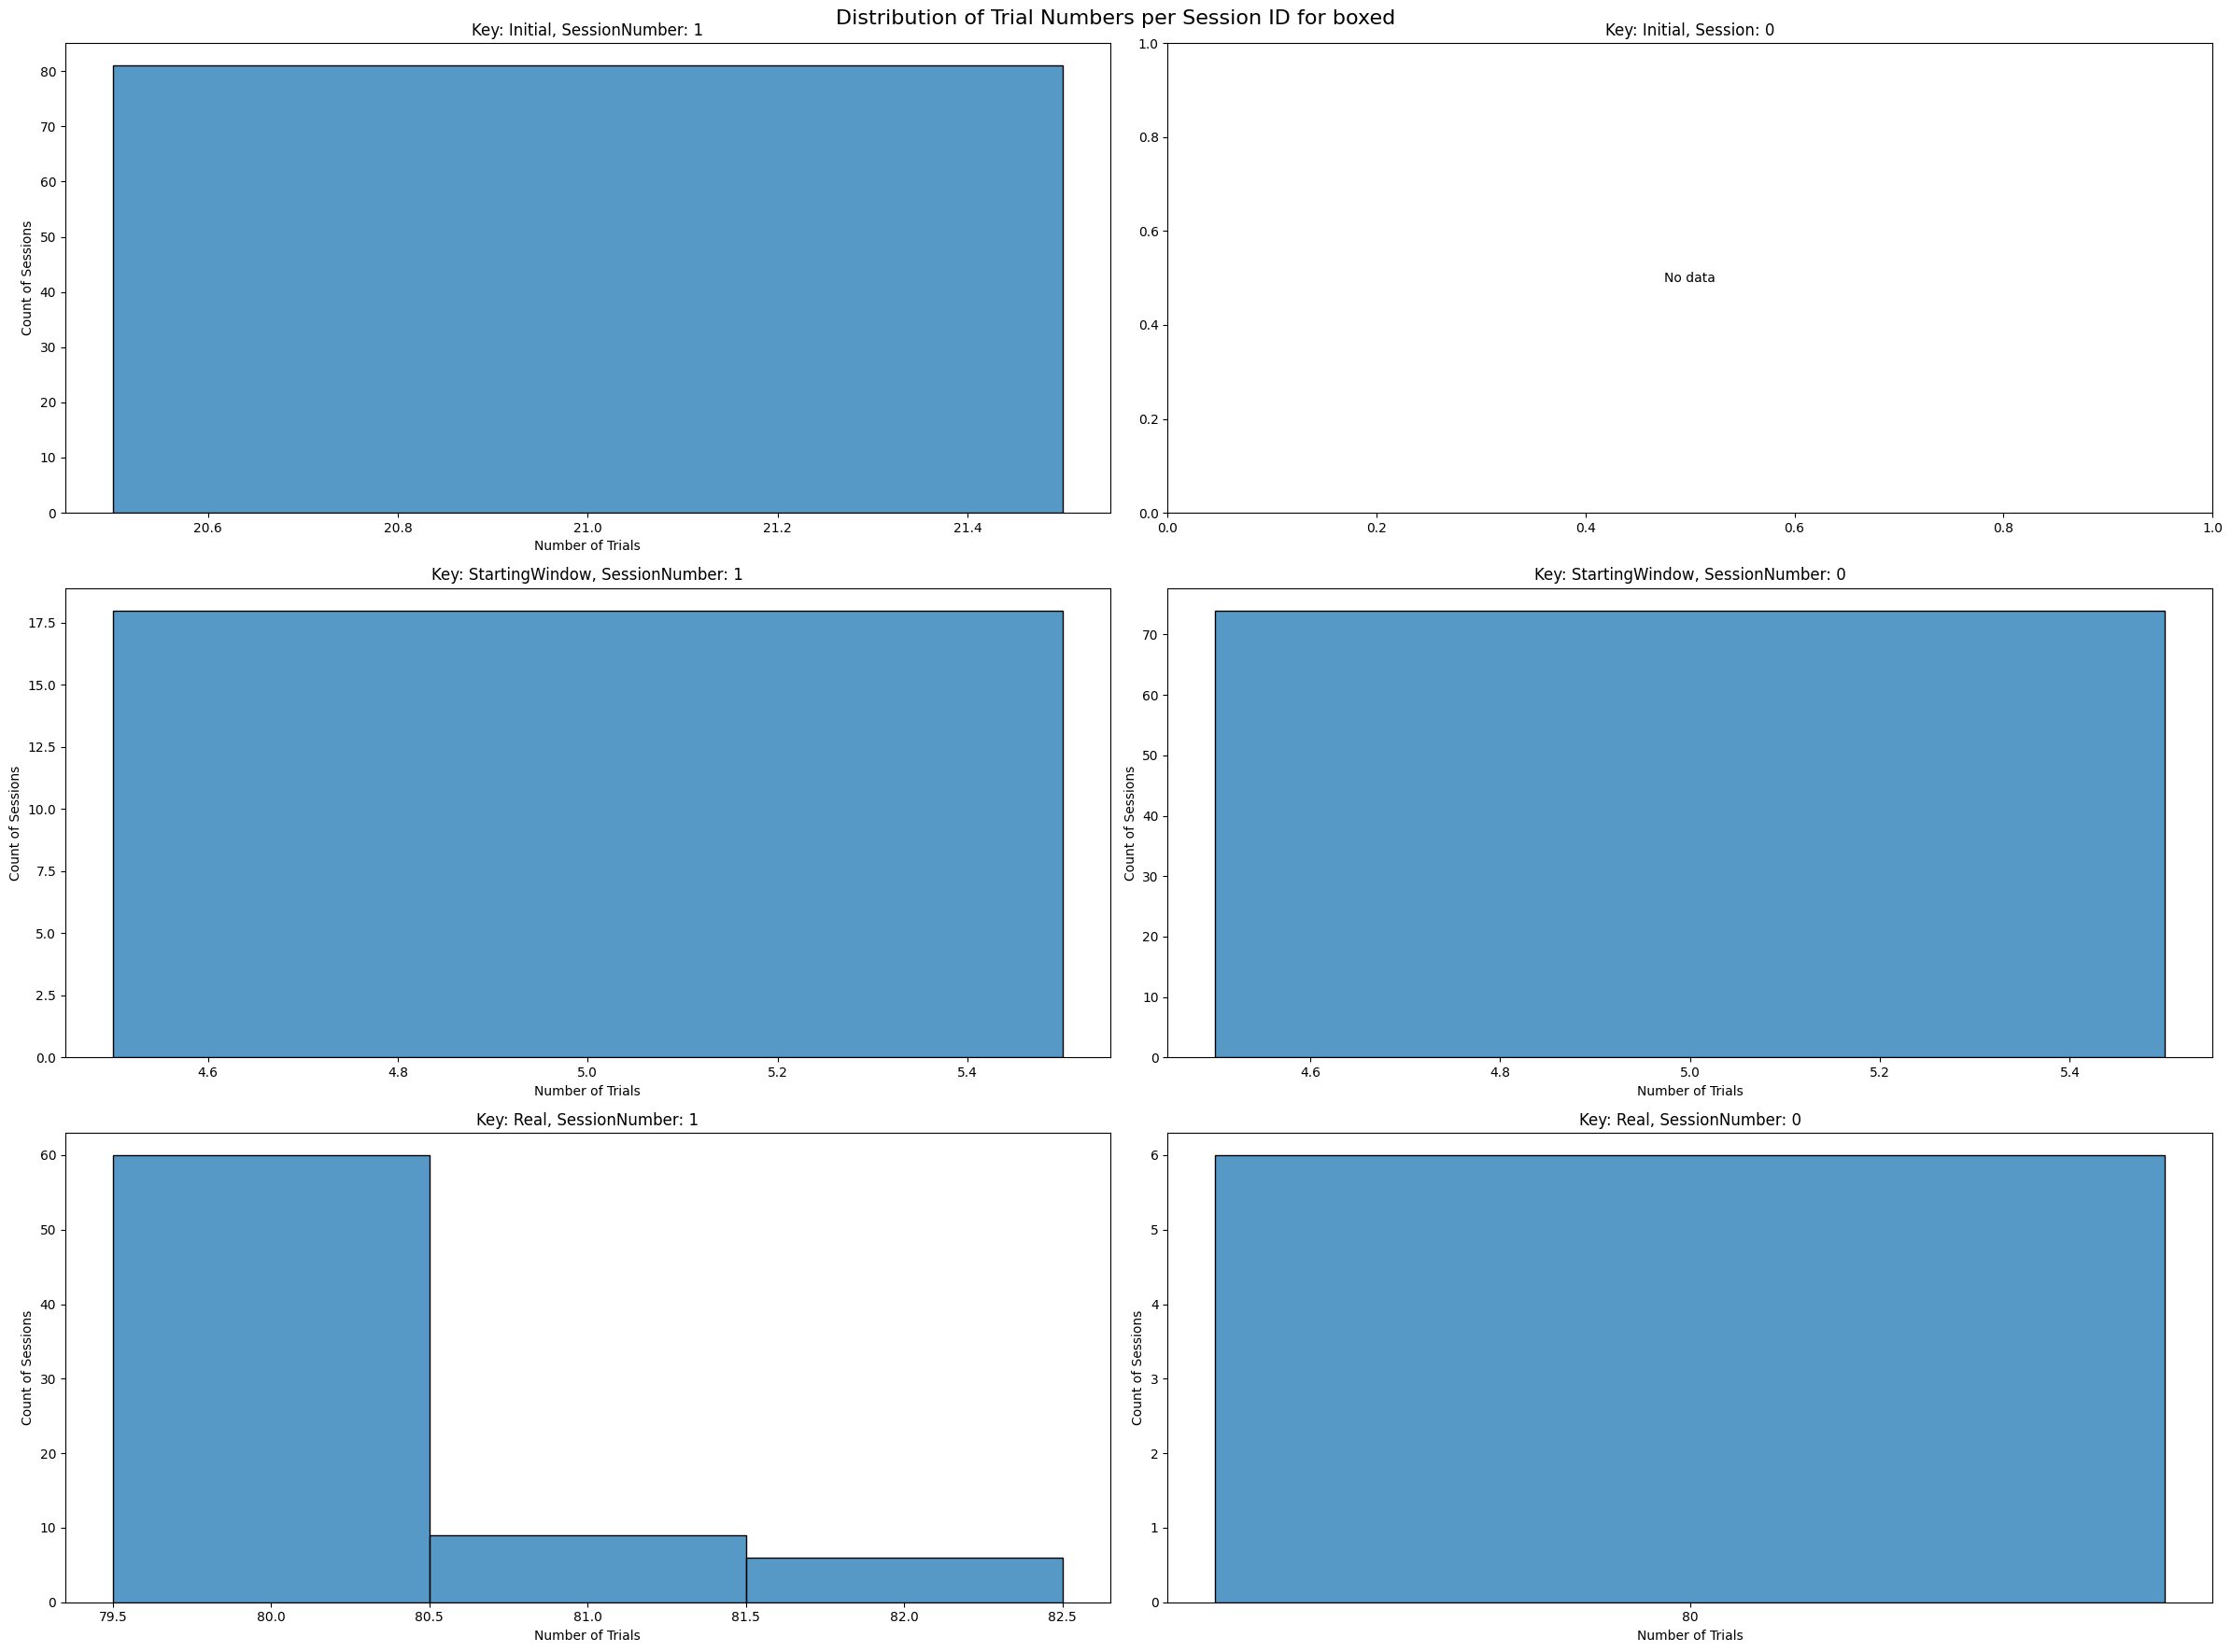

<Figure size 1200x600 with 0 Axes>

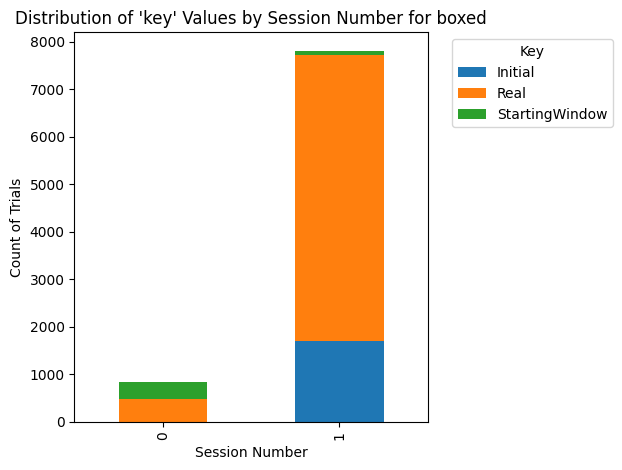

Unique values in sessionNumber: [1 0]
Unique values in session column: ['default' nan]
Count of rows for each sessionNumber:
sessionNumber
1    7812
0     846
Name: count, dtype: int64
Pivot table:
session        default
sessionNumber         
0                  NaN
1               7812.0


ValueError: Unknown format code 'd' for object of type 'float'

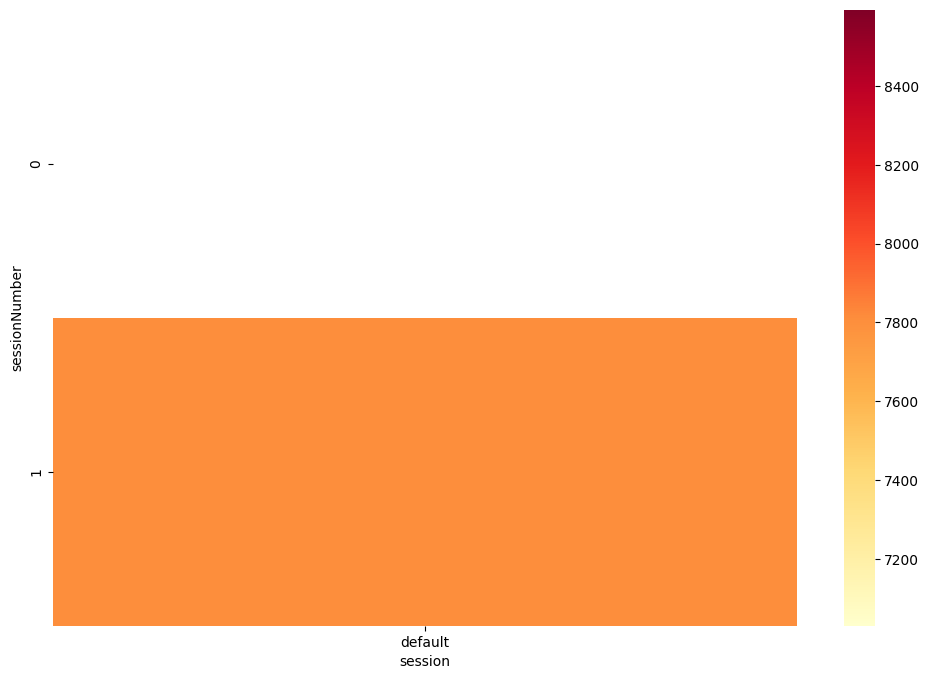

In [53]:
def analyze_session_numbers(df: pd.DataFrame):
    """
    Analyze the 'sessionNumber' column and generate analytics reports.
    Displays plots interactively instead of saving them to files.
    """
    if COL_GAME_TYPE in df.columns:
        gametype = df[COL_GAME_TYPE].iloc[0].lower()
    else:
        gametype = "unknown"
    print(f"Analyzing session numbers for file: {gametype}")

    # Basic Statistics
    session_counts = df['sessionNumber'].value_counts().sort_index()
    print("Session Number Distribution:")
    print(session_counts)

    # Plot session distribution
    # Convert sessionCompletedUtc to PST and plot against sessionNumber
    df['sessionCompletedPST'] = pd.to_datetime(df['sessionCompletedUtc']).dt.tz_convert('US/Pacific')
    
    plt.figure(figsize=(12, 6))
    for session in [0, 1]:
        session_data = df[df['sessionNumber'] == session]
        plt.scatter(session_data['sessionCompletedPST'], [session] * len(session_data), 
                    label=f'Session {session}', alpha=0.6)
    
    plt.title(f"Session Number vs Completion Time (PST) for {gametype}")
    plt.xlabel("Session Completion Time (PST)")
    plt.ylabel("Session Number")
    plt.yticks([0, 1])
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Count unique PIDs for each sessionNumber
    unique_pids_per_session = df.groupby('sessionNumber')['participantId'].nunique()

    # Plot unique PIDs per sessionNumber
    plt.figure(figsize=(8, 6))
    sns.barplot(x=unique_pids_per_session.index, y=unique_pids_per_session.values)
    plt.title(f"Number of Unique Participants per Session Number for {gametype}")
    plt.xlabel("Session Number")
    plt.ylabel("Number of Unique Participants")
    plt.show()
    plt.close()

    keys = df['key'].unique()

    # Create a figure with three subplots side by side
    keys = df['key'].unique()
    session_numbers = df['sessionNumber'].unique()

    # Create a figure with subplots for each key and sessionNumber combination
    fig, axes = plt.subplots(len(keys), len(session_numbers), figsize=(24, 6 * len(keys)))
    fig.suptitle(f"Distribution of Trial Numbers per Session ID for {gametype}", fontsize=16)

    for i, key in enumerate(keys):
        for j, session_num in enumerate(session_numbers):
            df_filtered = df[(df['key'] == key) & (df['sessionNumber'] == session_num)]
            trials_per_sessionId = df_filtered.groupby('sessionId')['trialNumber'].max() + 1 # since this is 0 indexed
            if len(trials_per_sessionId) > 0:
                min_trials = int(trials_per_sessionId.min())
                max_trials = int(trials_per_sessionId.max())
                bins = range(min_trials, max_trials + 2)  # +2 to include the max value
                plt.xticks(range(min_trials, max_trials + 1))
                
                ax = axes[i][j] if len(keys) > 1 else axes[j]
                sns.histplot(trials_per_sessionId, bins=bins, ax=ax, discrete=True)
                ax.set_title(f"Key: {key}, SessionNumber: {session_num}")
                ax.set_xlabel("Number of Trials")
                ax.set_ylabel("Count of Sessions")
            else:
                ax = axes[i][j] if len(keys) > 1 else axes[j]
                ax.text(0.5, 0.5, "No data", ha='center', va='center')
                ax.set_title(f"Key: {key}, Session: {session_num}")

    plt.tight_layout()
    plt.show()
    
    plt.close()

    plt.figure(figsize=(12, 6))
    key_counts = df.groupby(['sessionNumber', 'key']).size().unstack(fill_value=0)
    key_counts.plot(kind='bar', stacked=True)
    plt.title(f"Distribution of 'key' Values by Session Number for {gametype}")
    plt.xlabel("Session Number")
    plt.ylabel("Count of Trials")
    plt.legend(title='Key', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    plt.close()

    print("Unique values in sessionNumber:", df['sessionNumber'].unique())
    print("Unique values in session column:", df['session'].unique())
    print("Count of rows for each sessionNumber:")
    print(df['sessionNumber'].value_counts())

    # Create pivot table
    pivot = pd.pivot_table(df, values='trialNumber', index='sessionNumber', 
                           columns='session', aggfunc='count', fill_value=0)
    
    # Ensure both 0 and 1 are in the index
    pivot = pivot.reindex([0, 1])
    
    # If 'session' column only contains '' and 'default', rename '' to 'empty'
    if set(pivot.columns) == {'', 'default'}:
        pivot = pivot.rename(columns={'': 'empty'})
    
    print("Pivot table:")
    print(pivot)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
    plt.title(f"Heatmap of Session Numbers vs Session Type for {gametype}")
    plt.xlabel("Session Type")
    plt.ylabel("Session Number")
    plt.show()
    plt.close()



analyze_session_numbers(boxed)

Number of unique participantTaskIds per sessionId:
sessionId
0087c624-f7fc-44d5-976c-e124165dd348    1
00c77efe-3d39-4520-8184-b0f81e60f9de    1
0114ca70-79eb-4445-a460-e6468dfddbdd    1
01caf777-4f05-4808-828e-e5546b40c186    1
022ec5ed-6c8a-4fef-9b04-b567f12f1967    1
                                       ..
fc4e6f5b-55eb-4dcf-addd-0454d896a8e9    1
fdb9bd0b-9a88-485b-8067-d4adf7e7cd6c    1
fdeb1e9c-92af-4b5b-a668-ba8c230fcb9e    1
fe16823b-5504-407d-b729-0e0d1321aad3    1
fe7b0a5a-3aa6-4096-aac7-ffeb809f06b4    1
Name: participantTaskId, Length: 254, dtype: int64

Number of unique sessionIds per participantTaskId:
participantTaskId
0110a616-fc10-4351-aefe-7bdba871cb46    3
0128e11c-f749-4c37-b76f-47fb0b894752    3
02418a66-cff0-45c2-9453-cf4a7741cb03    3
0504a290-5512-4aca-a047-54a14a9a41de    3
05e97f0e-8972-45aa-b0e7-626ea7ccf410    3
                                       ..
ef18df79-2e86-4a81-82ee-d662e24ab26f    3
f47d6530-f7fc-4058-adf5-f2c7378f4d86    3
fd92eb93-aebd-4df9-b

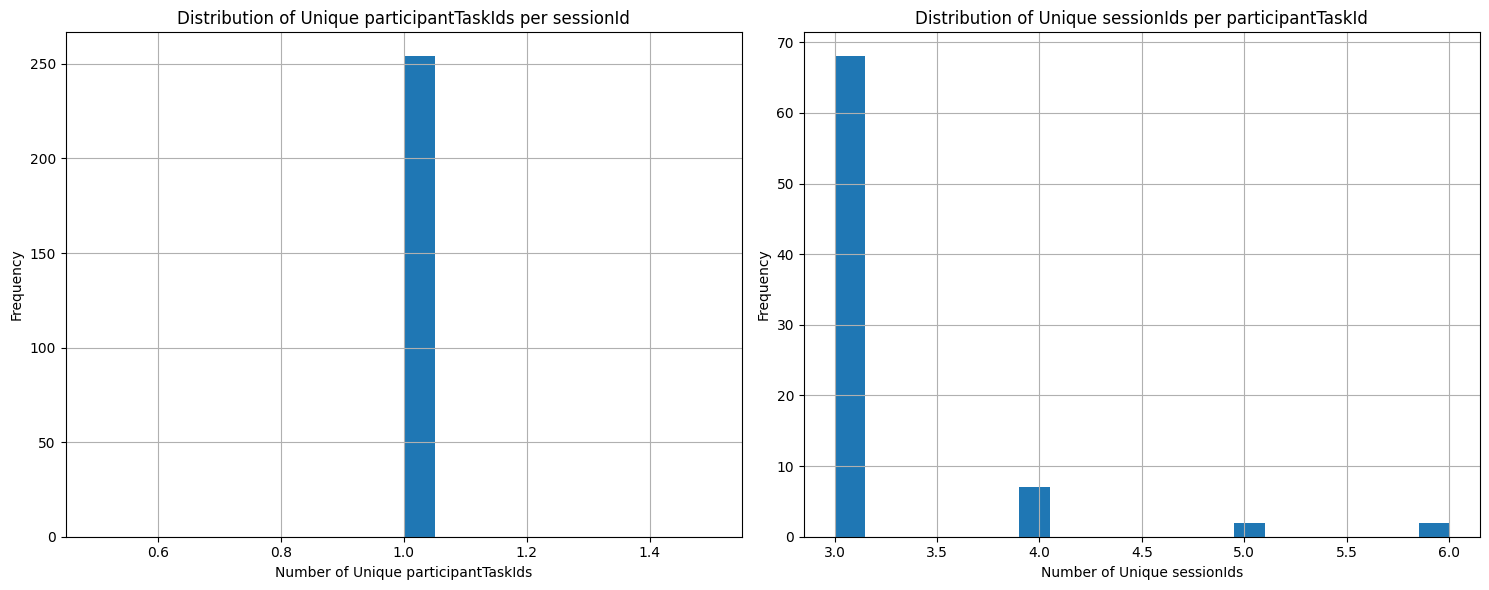

(sessionId
 0087c624-f7fc-44d5-976c-e124165dd348    1
 00c77efe-3d39-4520-8184-b0f81e60f9de    1
 0114ca70-79eb-4445-a460-e6468dfddbdd    1
 01caf777-4f05-4808-828e-e5546b40c186    1
 022ec5ed-6c8a-4fef-9b04-b567f12f1967    1
                                        ..
 fc4e6f5b-55eb-4dcf-addd-0454d896a8e9    1
 fdb9bd0b-9a88-485b-8067-d4adf7e7cd6c    1
 fdeb1e9c-92af-4b5b-a668-ba8c230fcb9e    1
 fe16823b-5504-407d-b729-0e0d1321aad3    1
 fe7b0a5a-3aa6-4096-aac7-ffeb809f06b4    1
 Name: participantTaskId, Length: 254, dtype: int64,
 participantTaskId
 0110a616-fc10-4351-aefe-7bdba871cb46    3
 0128e11c-f749-4c37-b76f-47fb0b894752    3
 02418a66-cff0-45c2-9453-cf4a7741cb03    3
 0504a290-5512-4aca-a047-54a14a9a41de    3
 05e97f0e-8972-45aa-b0e7-626ea7ccf410    3
                                        ..
 ef18df79-2e86-4a81-82ee-d662e24ab26f    3
 f47d6530-f7fc-4058-adf5-f2c7378f4d86    3
 fd92eb93-aebd-4df9-b57a-ec8ec4e2aa68    3
 fea2877f-15a4-415b-a9c6-14b811a72a93    3
 ff2232a6-f2dc

In [52]:
def analyze_session_participant_relationships(df: pd.DataFrame):
    """
    Analyze the relationship between sessionId and participantTaskId.
    
    Returns:
    - sessions_count: Series with sessionId as index and count of unique participantTaskIds
    - participants_count: Series with participantTaskId as index and count of unique sessionIds
    """
    # Count unique participantTaskIds for each sessionId
    sessions_count = df.groupby('sessionId')['participantTaskId'].nunique()
    
    # Count unique sessionIds for each participantTaskId
    participants_count = df.groupby('participantTaskId')['sessionId'].nunique()
    
    print("Number of unique participantTaskIds per sessionId:")
    print(sessions_count)
    print("\nNumber of unique sessionIds per participantTaskId:")
    print(participants_count)
    
    # Visualize the distributions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    sessions_count.hist(ax=ax1, bins=20)
    ax1.set_title("Distribution of Unique participantTaskIds per sessionId")
    ax1.set_xlabel("Number of Unique participantTaskIds")
    ax1.set_ylabel("Frequency")
    
    participants_count.hist(ax=ax2, bins=20)
    ax2.set_title("Distribution of Unique sessionIds per participantTaskId")
    ax2.set_xlabel("Number of Unique sessionIds")
    ax2.set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()
    
    return sessions_count, participants_count

analyze_session_participant_relationships(boxed)

In [40]:
participants_count = boxed.groupby('participantTaskId')['sessionId'].nunique()
greater_than_one = participants_count[participants_count > 1]